# Notebook for conducting the main sizing of the 5 design options for trade-off

In [2]:
import sys
import os
import matplotlib.pyplot as plt
import numpy.typing as nt
import aerosandbox.numpy as np

# Add the 'src' directory to the python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))

from src.Sizing_Loop.SizingForTradeoff import SizingForTradeoff, DesignOptionState

## Generating the initial values and decisions for design options

In [3]:
sizing_for_tradeoff = SizingForTradeoff()

for configuration in sizing_for_tradeoff.configurations:
    print()
    print(configuration.name)
    print("high wing" if np.isclose(configuration.wing_interference_factor, 1.) else "low wing")
    print("movable wing port" if configuration.main_wing_x_movable else "fixed wing port")
    print("canard capability" if configuration.canard_capability else "no canard port")
    print("sideways extending landing gear" if configuration.landing_gear_sideways_extendable else "downwards extending landing gear")


HUG-CFG-301
low wing
movable wing port
canard capability
sideways extending landing gear

HUG-CFG-302
high wing
fixed wing port
no canard port
downwards extending landing gear

HUG-CFG-303
high wing
fixed wing port
canard capability
sideways extending landing gear

HUG-CFG-304
high wing
movable wing port
canard capability
downwards extending landing gear

HUG-CFG-305
high wing
movable wing port
canard capability
sideways extending landing gear


## Specifying the settings of the analysis

In [4]:
sizing_for_tradeoff.accumulate_steps()

In [5]:
def tracked_varaibles(state:DesignOptionState) -> nt.NDArray[np.float64]:
    return np.array([
        state.iterable.aircraft_parameters.total_mass
    ])

In [6]:
n_iterations = 6

## Running the analysis

In [7]:
sizing_results = sizing_for_tradeoff.size_options_for_tradeoff(n_iterations, tracked_varaibles)

print(sizing_results)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.49795418253271856
            Iterations: 4
            Function evaluations: 17
            Gradient evaluations: 4
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.4869322781314943
            Iterations: 4
            Function evaluations: 17
            Gradient evaluations: 4
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.4809575862911635
            Iterations: 4
            Function evaluations: 17
            Gradient evaluations: 4
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.4784179391406263
            Iterations: 4
            Function evaluations: 17
            Gradient evaluations: 4
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.47864737190272316
            Iterations: 4
            Function evaluation

## Postprocessing the analysis

[[ 50.         252.26986241 180.03319404 174.95972441 175.16220133
  175.41443861 175.41004563]]
[[ 50.         252.26986241 176.76665932 168.82709056 169.08930112
  169.09703362 169.09651834]]
[[ 50.         252.26986241 176.69501798 168.60951567 168.60871477
  168.87604062 168.87257144]]
[[ 50.         252.26986241 176.76665932 168.82709056 169.08930112
  169.09703362 169.09651834]]
[[ 50.         252.26986241 176.69501798 168.60951567 168.60871477
  168.87604062 168.87257144]]


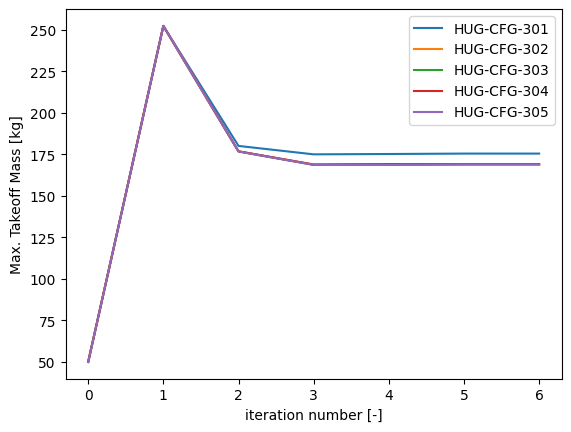

In [ ]:
for design_option, convergence_history in sizing_results:
    print(convergence_history)
    print(design_option)
    plt.plot(list(range(n_iterations+1)), convergence_history[0], label=design_option.state.fixed.choices.name)
    
plt.ylabel("Max. Takeoff Mass [kg]")
plt.xlabel("iteration number [-]")
plt.legend()